In [2]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd 
import matplotlib.pyplot as plt
import plotly.io as pio
pio.renderers.default='browser'
import pyarrow.feather as feather
import plotly.express as px
import numpy as np


In [4]:
#density_data = pd.read_csv("Data/cluster_0_data.csv", low_memory=False) # Kevitsa
enterprise_data = feather.read_feather("C:/Users/lin236/OneDrive - CSIRO/Minerals4D/Projects/SandS_DS/Parker Challenge 2025/Enterprise_pre2010_Desurvey.csv")

In [5]:
df = enterprise_data.copy()


#filtered_samples = df.dropna(subset=['Alt1_Code', 'Alt2_Code', 'Density_gcm3'])
filtered_samples = df.dropna(subset=['Au_ppm', 'As_ppm_BESTEL', 'Hg_ppm_BESTEL'])
filtered_samples = filtered_samples.iloc[::2] # Randomly select half of the samples

sample_count = len(filtered_samples)


#print(f"Number of samples with alteration and Density_gcm3 data: {sample_count}")
print(f"Number of samples with gold and pathfinder (As, Hg) data: {sample_count}")



Number of samples with gold and pathfinder (As, Hg) data: 92285


In [6]:
# log transform the data
filtered_samples['Log_Au_ppm'] = np.log(filtered_samples['Au_ppm'])

# Create 3D scatter plot
fig = px.scatter_3d(filtered_samples, \
                    x='X', y='Y', z='Z', \
                        color='Log_Au_ppm', size='Au_ppm', \
                        opacity=0.7, labels={'Log_Au_ppm': 'Gold log(ppm)'})

fig.update_traces(marker=dict(line=dict(width=0)))
# Show plot
fig.show()

In [7]:
mineral = 'Au_ppm'
#filter = ['Sulph1_Code', 'Sulph1_Pct', 'Sulph2_Code', 'Sulph2_Pct']
#deposit_data = density_data

#deposit_data = deposit_data.dropna(subset=[mineral] + filter)
deposit_data = filtered_samples
#df1 = deposit_data
df1 = filtered_samples
variable = mineral

In [9]:
two_composite_1covariates = deposit_data

missing_percentage = (two_composite_1covariates.isnull().sum() / len(two_composite_1covariates)) * 100

variables_to_remove = missing_percentage[missing_percentage > 5].index

two_composite_1covariates = two_composite_1covariates.drop(columns=variables_to_remove)


encoded_data = two_composite_1covariates.copy()

threshold = 10

for column in two_composite_1covariates.columns:
    if two_composite_1covariates[column].dtype == 'object':
        unique_values = two_composite_1covariates[column].nunique()
        
        if unique_values <= threshold:
            encoded_columns = pd.get_dummies(encoded_data[column], prefix=column)
            encoded_columns = encoded_columns.astype(int)  
            encoded_data = pd.concat([encoded_data, encoded_columns], axis=1)
            encoded_data = encoded_data.drop(columns=[column])




encoded_columns = [col for col in encoded_data.columns if '_Code_' in col]

total_columns = []

for col in encoded_columns:
    prefix, original_column = col.split('_Code_')
    
    total_column = f"{original_column}_Total"
    total_columns.append(total_column)
    
    encoded_data[total_column] = (
        encoded_data[f"{prefix}_Code_{original_column}"] * encoded_data[f"{prefix}_Pct"]
    )

total_columns = []

category_totals = {}

for col in encoded_columns:
    prefix, original_column = col.split('_Code_')
    
    total_column = f"{original_column}_Total"
    if total_column not in total_columns:
        total_columns.append(total_column)
    
    total_values = encoded_data[f"{prefix}_Code_{original_column}"] * encoded_data[f"{prefix}_Pct"]
    
    if total_column in category_totals:
        category_totals[total_column] += total_values
    else:
        category_totals[total_column] = total_values

for total_column, total_values in category_totals.items():
    encoded_data[total_column] = total_values


In [10]:
variable_names = ['Sc_ppm',
 'Al_pct',
 'Y_ppm',
 'V_ppm',
 'Sr_ppm',
 'Ca_pct',
 'P_ppm',
 'Si_pct',
 'Li_ppm',
 'Mg_pct',
 'La_ppm',
 'RQD_Pct',
 'Alt1_Int_wk',
 'Ba_ppm',
 'Sulph1_Code_PO',
 'IP_pct',
 'Sulph2_Code_CP',
 'Sulph2_Code_PO',
 'X',
 'PY_Total',
 'Z',
 'PO_Total',
 'CP_Total',
 'Cr_ppm',
 'B_ppm',
 'Y',
 'Sb_ppm',
 'Weathering']

In [9]:
filtered_encoded_data = encoded_data[encoded_data.columns.intersection(variable_names+ ['Density_gcm3', 'Name'])]

deposit_data = encoded_data[['Name', 'X', 'Y', 'Z', 'Density_gcm3', 'RQD_Pct', 'Cr_ppm', 'CP_Total',
       'PO_Total', 'PY_Total']]
total_columns = ['CP_Total','PO_Total', 'PY_Total']


deposit_data.describe()
deposit_data.fillna(0, inplace=True)
deposit_data

NameError: name 'encoded_data' is not defined

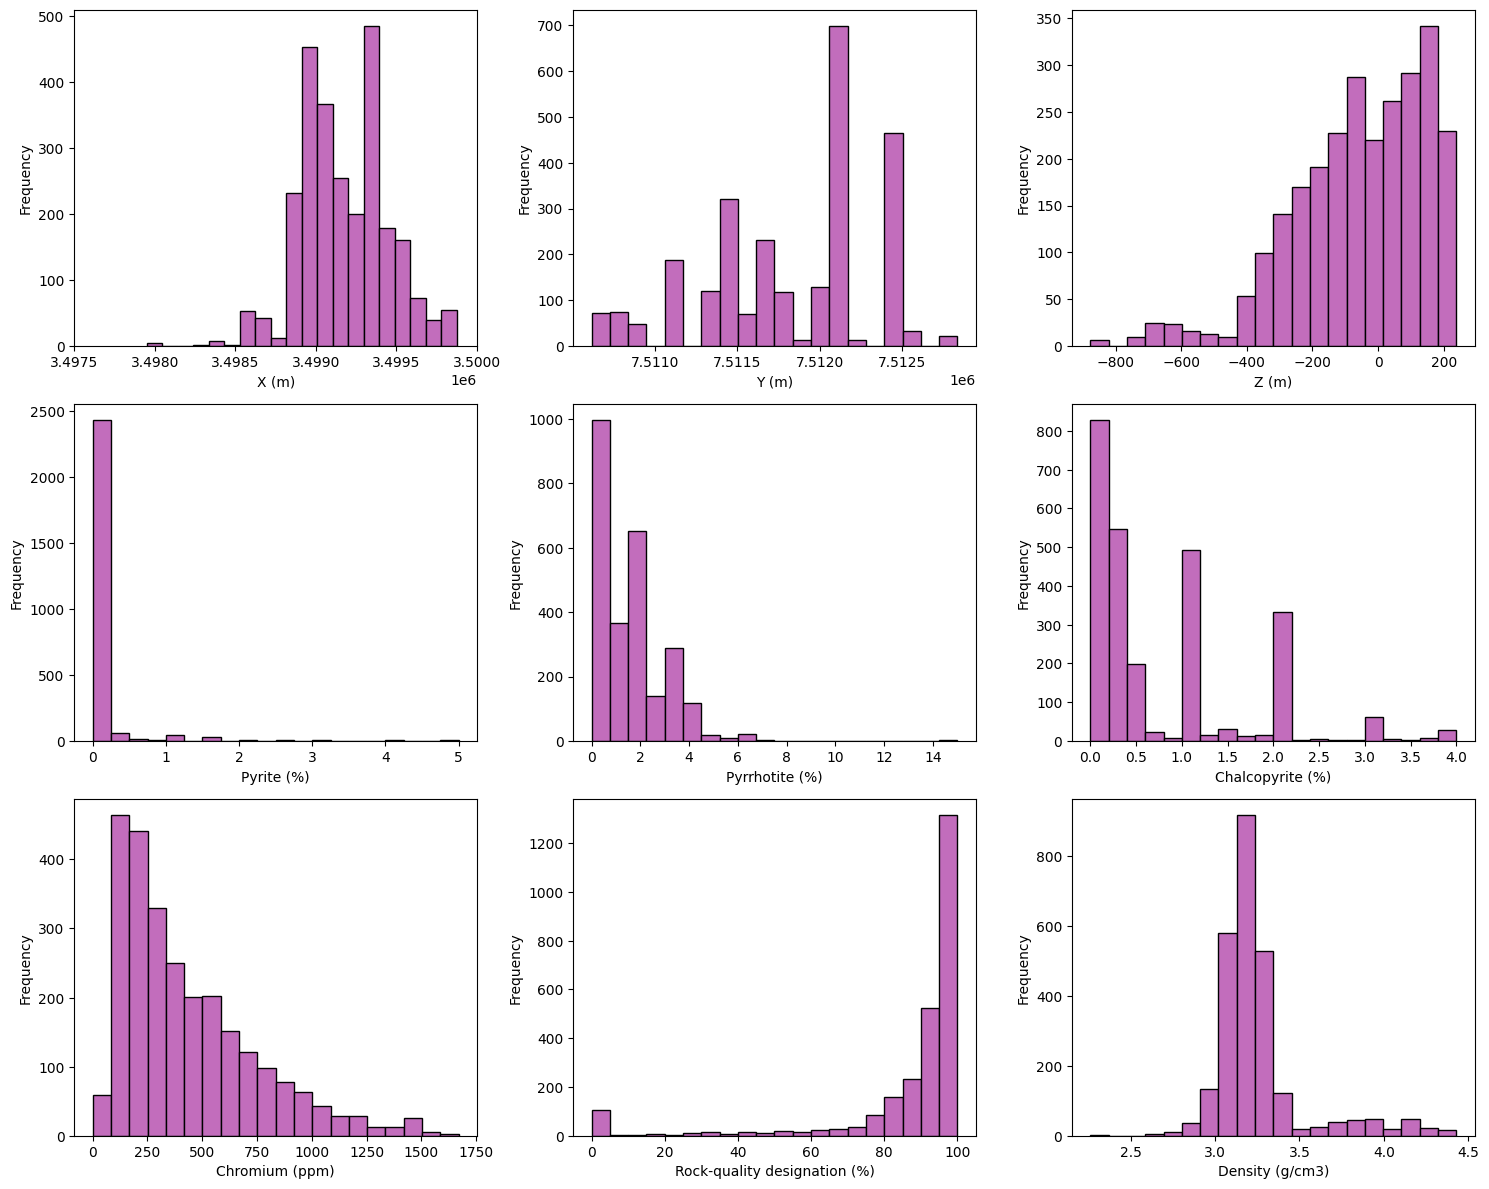

In [10]:
variables = ['X', 'Y', 'Z', 'PY_Total', 'PO_Total', 'CP_Total', 'Cr_ppm', 'RQD_Pct', 'Density_gcm3']

variables2 = ['X (m)', 'Y (m)', 'Z (m)', 'Pyrite (%)', 'Pyrrhotite (%)', 'Chalcopyrite (%)', 'Chromium (ppm)', 'Rock-quality designation (%)', 'Density (g/cm3)']
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))

for i, var in enumerate(variables):
    row = i // 3
    col = i % 3
    axs[row, col].hist(deposit_data[var], bins=20, color='#C26DBC', edgecolor='black')
    axs[row, col].set_xlabel(str(variables2[i]))
    axs[row, col].set_ylabel('Frequency')
    axs[row, col].grid(False)
    if var == 'X':
        x_ticks = axs[row, col].get_xticks()
        x_ticks = x_ticks[::1]  
        axs[row, col].set_xticks(x_ticks)

plt.tight_layout()
plt.show()


c:\Users\lin236\Anaconda3\envs\Loop\lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning:

divide by zero encountered in log



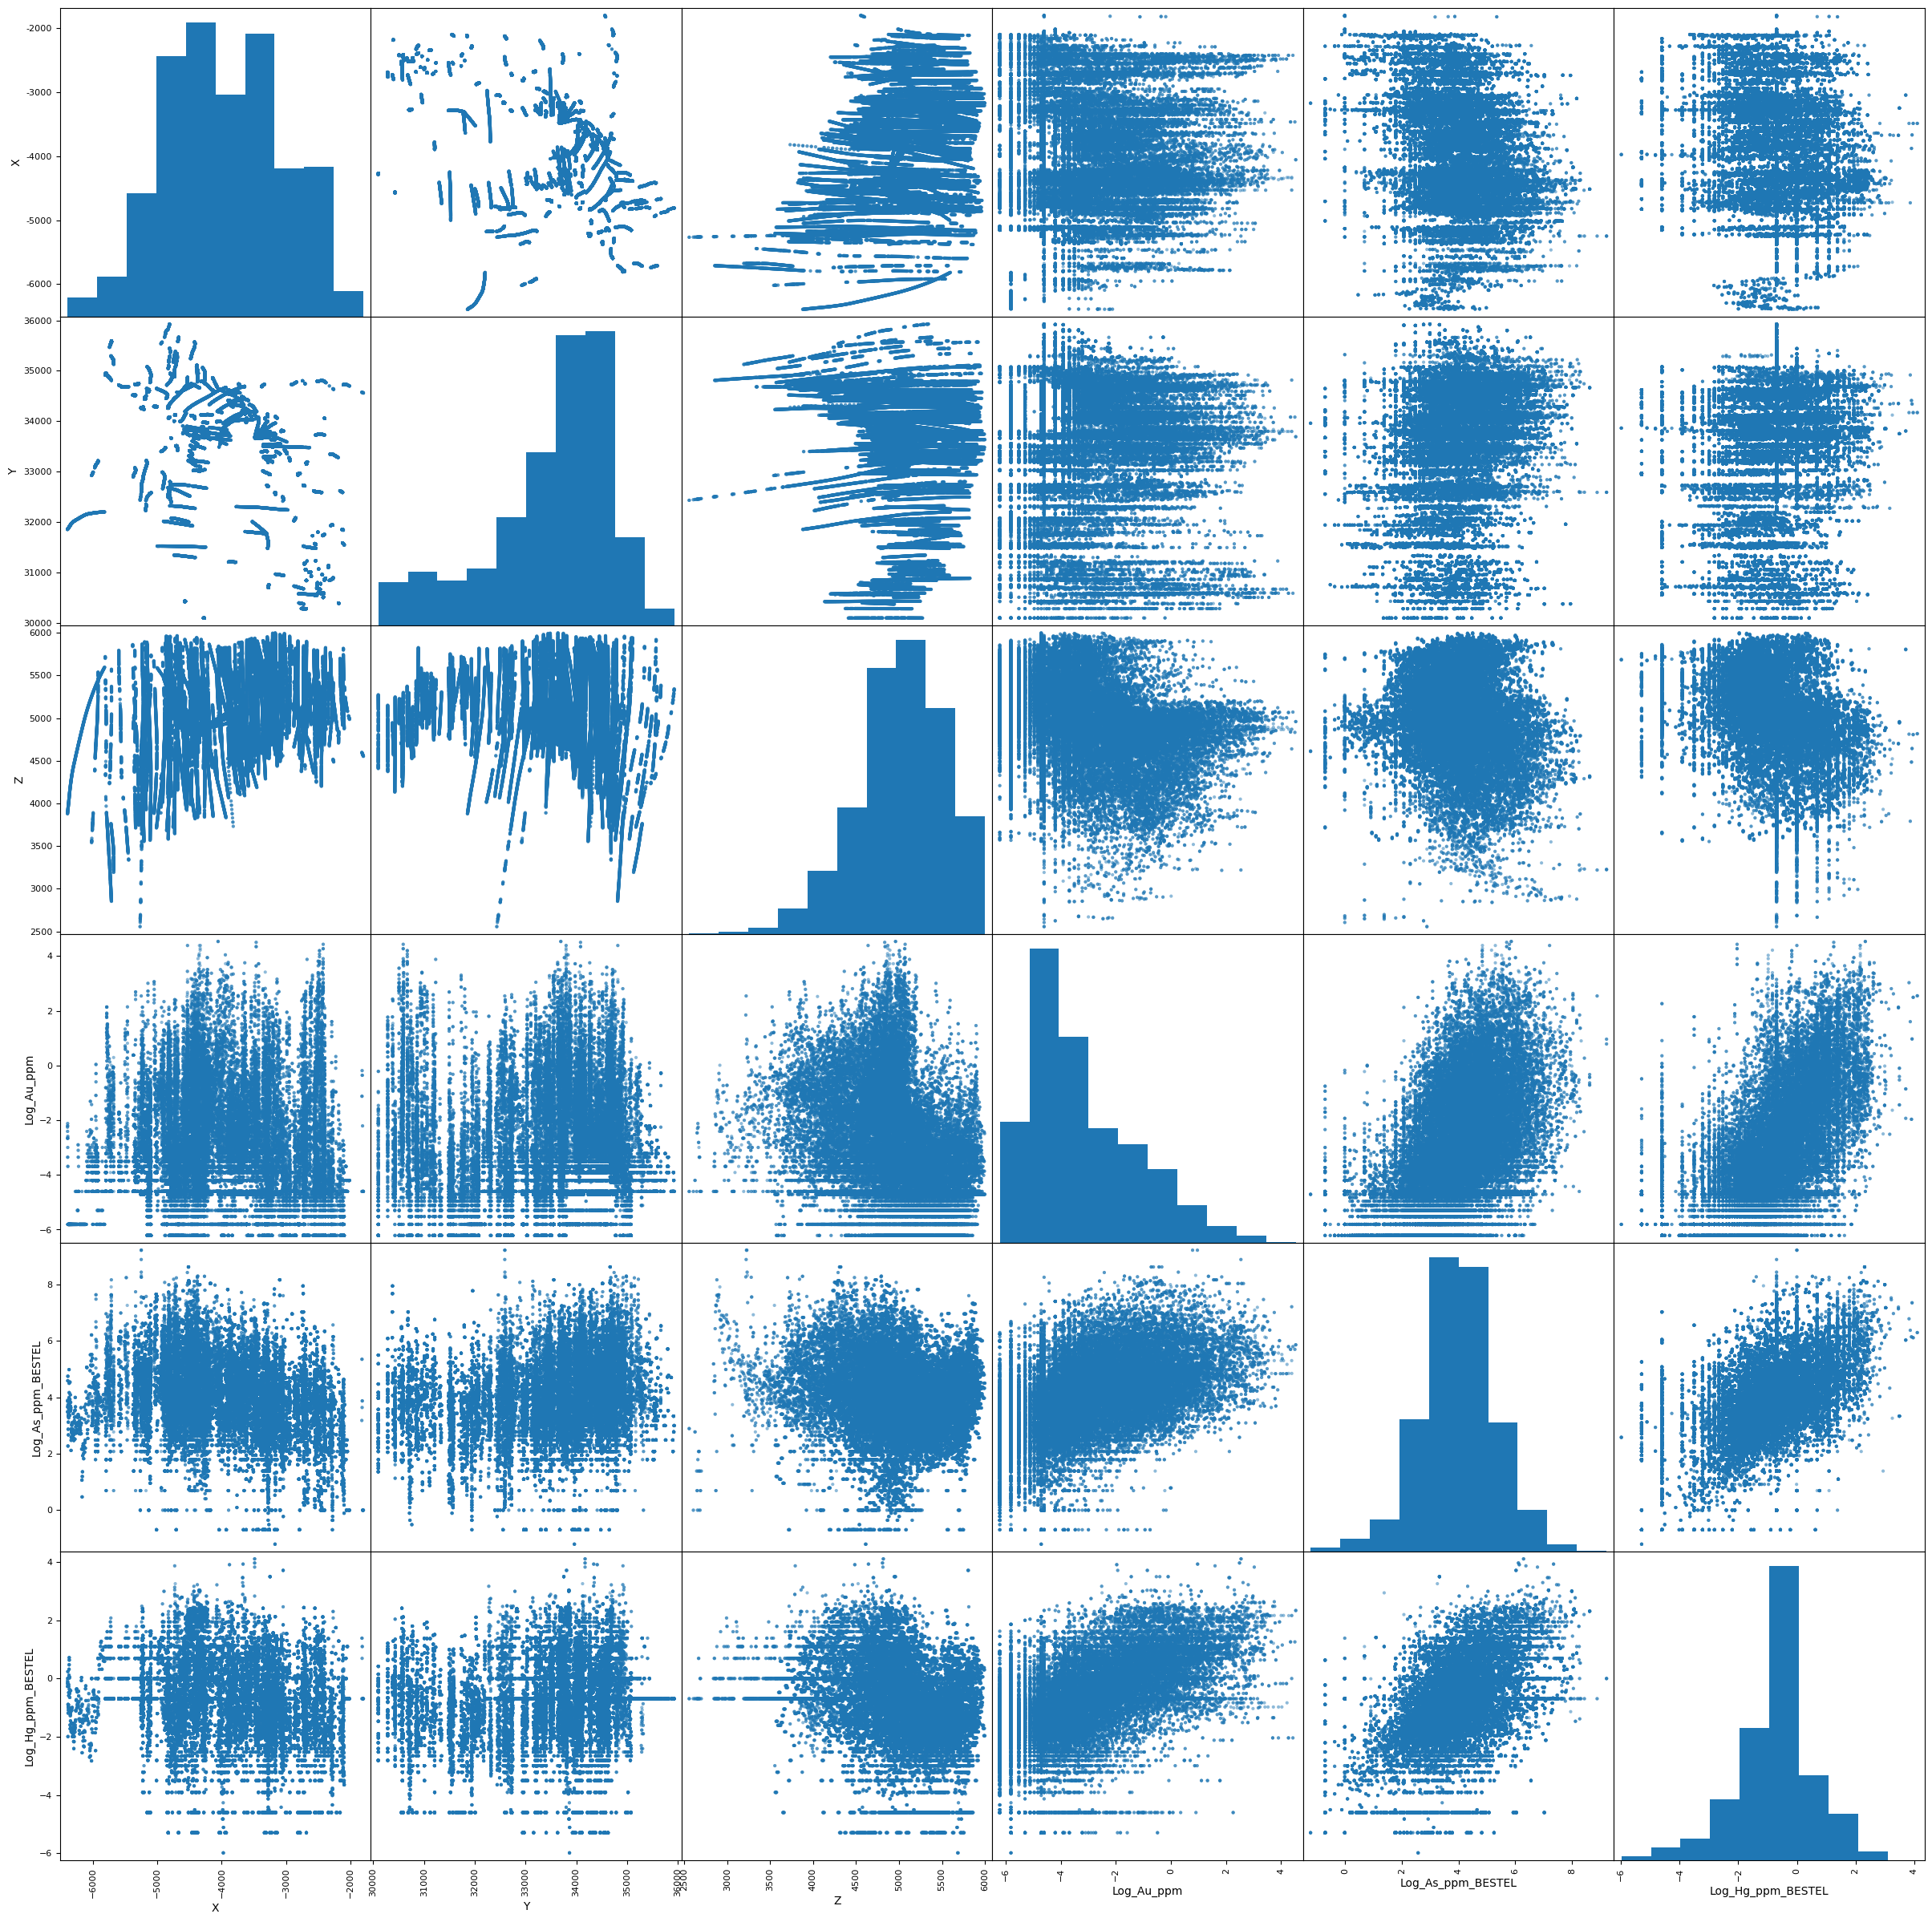

In [8]:
deposit_data['Log_Au_ppm'] = np.log(deposit_data['Au_ppm'])
deposit_data['Log_As_ppm_BESTEL'] = np.log(deposit_data['As_ppm_BESTEL'])
deposit_data['Log_Hg_ppm_BESTEL'] = np.log(deposit_data['Hg_ppm_BESTEL'])
columns = ['X', 'Y', 'Z', 'Log_Au_ppm', 'Log_As_ppm_BESTEL', 'Log_Hg_ppm_BESTEL']
cleaned_data = deposit_data[columns].replace([np.inf, -np.inf], np.nan).dropna()
scatter_matrix = pd.plotting.scatter_matrix(cleaned_data[columns], figsize=(30, 30))


#import seaborn as sns

# columns = ['X', 'Y', 'Z', 'CP_Total', 'PO_Total', 'PY_Total', 'RQD_Pct', 'Cr_ppm', 'Density_gcm3']
# sns.pairplot(deposit_data[columns], diag_kind='kde', corner=True)

In [14]:
summary = deposit_data.describe().round(3)

latex_table = summary.to_latex()

C:\Users\lin236\AppData\Local\Temp\ipykernel_18116\2957715656.py:3: FutureWarning:

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.



In [15]:
#deposit_data.to_csv('Data/filtered_unnormalised_deposit_data.csv', index=False)


In [9]:
columns_to_normalize = ['X', 'Y', 'Z']   

min_values = deposit_data[columns_to_normalize].min()

for column in columns_to_normalize:
    deposit_data[column] = deposit_data[column] - min_values[column]

# Calculate the minimum and maximum values from all three variables
min_values = deposit_data[columns_to_normalize].min().min()
max_values = deposit_data[columns_to_normalize].max().max()

for column in columns_to_normalize:
    deposit_data[column] = (deposit_data[column] - min_values) / (max_values - min_values)

#Scale the rest of the covariates in their own scale
covariates = ['As_ppm_BESTEL', 'Hg_ppm_BESTEL']
scaler = MinMaxScaler()
deposit_data.loc[:, [mineral] +covariates] = scaler.fit_transform(deposit_data.loc[:,[mineral] + covariates])


In [10]:
all_indexes = deposit_data.index
all_indexes.to_series().to_csv('C:/Users/lin236/OneDrive - CSIRO/Minerals4D/Projects/SandS_DS/Parker Challenge 2025//indexes.csv', index=False)


In [11]:
deposit_data.to_csv('C:/Users/lin236/OneDrive - CSIRO/Minerals4D/Projects/SandS_DS/Parker Challenge 2025/filtered_deposit_data.csv', index=False)
